In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import gzip

# ---- USER INPUT ----

kraken_files = [
    "EED_gut_NoPAP_PNK_S3_R2_001_k2.csv",
    "EED_gut_PAP_PNK_S4_R2_001_k2.csv",
    "EED_gut_NoPAP_S1_R2_001_k2.csv",
    "EED_gut_PAP_S2_R2_001_k2.csv"
]

fastq_files = [
    "EED_gut_NoPAP_PNK_S3_R2_001_fastped.fastq",
    "EED_gut_PAP_PNK_S4_R2_001_fastped.fastq",
    "EED_gut_NoPAP_S1_R2_001_fastped.fastq",
    "EED_gut_PAP_S2_R2_001_fastped.fastq"
]
human_taxid = 9606
cutoff_fraction = 0.0005       # 0.05% of total reads
min_absolute_reads = 10        # minimum reads per taxon
# --------------------

# ---- FUNCTIONS ----
def count_fastq_reads(fastq_file):
    """Count reads in FASTQ (handles .gz)"""
    open_func = gzip.open if fastq_file.endswith(".gz") else open
    with open_func(fastq_file, "rt") as f:
        return sum(1 for _ in f) // 4

def count_filtered_reads(kraken_file, abundance_threshold=0.01):
    """
    Count reads for taxa whose relative abundance exceeds a threshold.
    Ensures each taxon is counted only once, summing all its reads.
    """
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    
    if df.empty:
        return 0
    
    # sum reads per taxon
    taxa_counts = df.groupby(2).size()
    total_reads = taxa_counts.sum()
    
    # keep taxa with relative abundance > threshold
    filtered_taxa = taxa_counts[taxa_counts / total_reads > abundance_threshold]
    return filtered_taxa.sum()


def count_filtered_unique_taxa(kraken_file, abundance_threshold=0.01):
    """
    Count unique taxa whose relative abundance exceeds a threshold.
    """
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    
    if df.empty:
        return 0
    
    # sum reads per taxon
    taxa_counts = df.groupby(2).size()
    total_reads = taxa_counts.sum()
    filtered_taxa = taxa_counts[taxa_counts / total_reads > abundance_threshold]
    return len(filtered_taxa)


/scratch/ipykernel_3859029/2277892566.py:38: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2277892566.py:57: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2277892566.py:38: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2277892566.py:57: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2277892566.py:38: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, hea

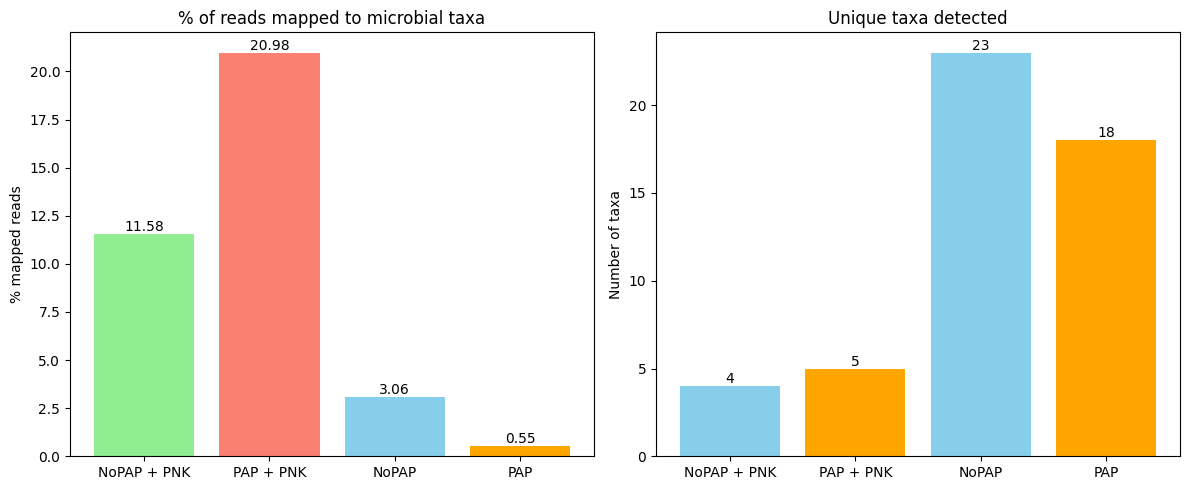

In [52]:
# ---- CALCULATE METRICS ----
percentages = []
unique_taxa_counts = []

for kfile, ffile in zip(kraken_files, fastq_files):
    total_reads = count_fastq_reads(ffile)
    mapped_reads = count_filtered_reads(kfile)
    percentages.append((mapped_reads / total_reads) * 100)  # % mapped reads
    unique_taxa_counts.append(count_filtered_unique_taxa(kfile))

# ---- SPLIT CONDITIONS ----
cond1_percent = percentages[:2]
cond2_percent = percentages[2:]
cond1_taxa = unique_taxa_counts[:2]
cond2_taxa = unique_taxa_counts[2:]

# ---- PLOTTING ----
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=False)

# Subplot 1: % mapped reads
axes[0].bar(["NoPAP + PNK", "PAP + PNK"], cond1_percent, color=["lightgreen", "salmon"])
axes[0].bar(["NoPAP", "PAP"], cond2_percent, color=["skyblue", "orange"])
axes[0].set_title("% of reads mapped to microbial taxa")
axes[0].set_ylabel("% mapped reads")
for i, val in enumerate(cond1_percent + cond2_percent):
    axes[0].text(i, val, f"{val:.2f}", ha="center", va="bottom")

# Subplot 2: unique taxa
axes[1].bar(["NoPAP + PNK", "PAP + PNK"], cond1_taxa, color=["skyblue", "orange"])
axes[1].bar(["NoPAP", "PAP"], cond2_taxa, color=["skyblue", "orange"])
axes[1].set_title("Unique taxa detected")
axes[1].set_ylabel("Number of taxa")
for i, val in enumerate(cond1_taxa + cond2_taxa):
    axes[1].text(i, val, str(val), ha="center", va="bottom")

plt.tight_layout()
plt.show()

/scratch/ipykernel_3859029/1256582427.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/1256582427.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/1256582427.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/1256582427.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/1256582427.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header

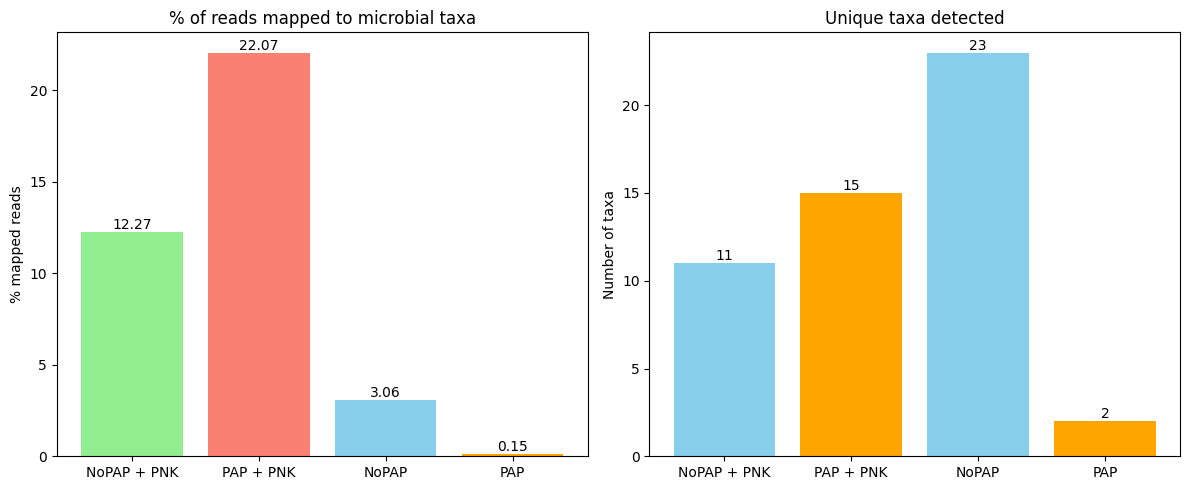

In [53]:
human_taxid = 9606
cutoff_fraction = 0.0005      # 0.05% of total reads
min_absolute_reads = 10       # minimum reads per taxon

def count_filtered_reads(kraken_file, total_reads, cutoff_fraction=cutoff_fraction, min_absolute_reads=min_absolute_reads):
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    taxa_counts = df[2].value_counts()
    min_reads = max(total_reads * cutoff_fraction, min_absolute_reads)
    taxa_counts = taxa_counts[taxa_counts >= min_reads]
    return taxa_counts.sum()

def count_filtered_unique_taxa(kraken_file, total_reads, cutoff_fraction=cutoff_fraction, min_absolute_reads=min_absolute_reads):
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    taxa_counts = df[2].value_counts()
    min_reads = max(total_reads * cutoff_fraction, min_absolute_reads)
    taxa_counts = taxa_counts[taxa_counts >= min_reads]
    return len(taxa_counts)

# ---- CALCULATE METRICS ----
percentages = []
unique_taxa_counts = []

for kfile, ffile in zip(kraken_files, fastq_files):
    total_reads = count_fastq_reads(ffile)  # total reads in FASTQ
    mapped_reads = count_filtered_reads(kfile, total_reads, cutoff_fraction, min_absolute_reads)
    percentages.append((mapped_reads / total_reads) * 100)  # % mapped reads
    unique_taxa_counts.append(count_filtered_unique_taxa(kfile, total_reads, cutoff_fraction, min_absolute_reads))

# ---- SPLIT CONDITIONS ----
cond1_percent = percentages[:2]
cond2_percent = percentages[2:]
cond1_taxa = unique_taxa_counts[:2]
cond2_taxa = unique_taxa_counts[2:]

# ---- PLOTTING ----
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=False)

# Subplot 1: % mapped reads
axes[0].bar(["NoPAP + PNK", "PAP + PNK"], cond1_percent, color=["lightgreen", "salmon"])
axes[0].bar(["NoPAP", "PAP"], cond2_percent, color=["skyblue", "orange"])
axes[0].set_title("% of reads mapped to microbial taxa")
axes[0].set_ylabel("% mapped reads")
for i, val in enumerate(cond1_percent + cond2_percent):
    axes[0].text(i, val, f"{val:.2f}", ha="center", va="bottom")

# Subplot 2: unique taxa
axes[1].bar(["NoPAP + PNK", "PAP + PNK"], cond1_taxa, color=["skyblue", "orange"])
axes[1].bar(["NoPAP", "PAP"], cond2_taxa, color=["skyblue", "orange"])
axes[1].set_title("Unique taxa detected")
axes[1].set_ylabel("Number of taxa")
for i, val in enumerate(cond1_taxa + cond2_taxa):
    axes[1].text(i, val, str(val), ha="center", va="bottom")

plt.tight_layout()
plt.show()

EED_mis_gut_NoPAPa_S7_L001_R2_001_k2.csv mapped reads: 31 unique taxa: 3
EED_mis_gut_NoPAPb_S9_L001_R2_001_k2.csv mapped reads: 101 unique taxa: 8
EED_mis_gut_PAPa_S8_L001_R2_001_k2.csv mapped reads: 17 unique taxa: 3
EED_mis_gut_PAPb_S10_L001_R2_001_k2.csv mapped reads: 30 unique taxa: 6


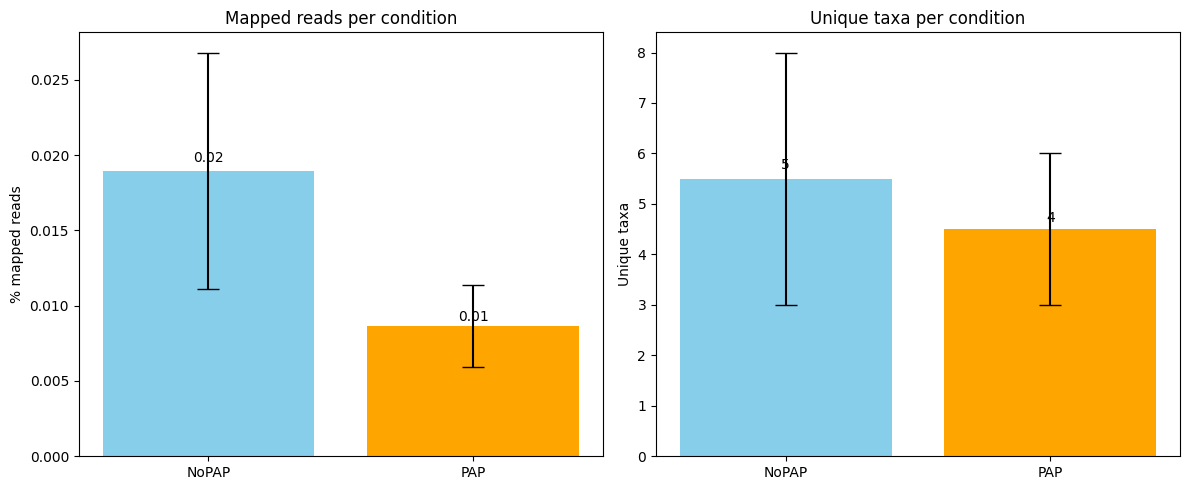

In [40]:
import pandas as pd
import gzip
import numpy as np
import matplotlib.pyplot as plt

# ---- USER INPUT ----
# Arrange files as 2 conditions x 2 replicates each
kraken_files = [
    "EED_mis_gut_NoPAPa_S7_L001_R2_001_k2.csv", "EED_mis_gut_NoPAPb_S9_L001_R2_001_k2.csv",
    "EED_mis_gut_PAPa_S8_L001_R2_001_k2.csv", "EED_mis_gut_PAPb_S10_L001_R2_001_k2.csv"
]

fastq_files = [
    "EED_mis_gut_NoPAPa_S7_L001_R2_001_fastped.fastq", "EED_mis_gut_NoPAPb_S9_L001_R2_001_fastped.fastq",
    "EED_mis_gut_PAPa_S8_L001_R2_001_fastped.fastq", "EED_mis_gut_PAPb_S10_L001_R2_001_fastped.fastq"
]

human_taxid = 9606
cutoff_fraction = 0.00001
min_absolute_reads = 1

# ---- FUNCTIONS (reuse previous) ----
def count_fastq_reads(fastq_file):
    open_func = gzip.open if fastq_file.endswith(".gz") else open
    with open_func(fastq_file, "rt") as f:
        return sum(1 for _ in f) // 4

def count_filtered_reads(kraken_file, total_reads):
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    taxa_counts = df[2].value_counts()
    min_reads = max(total_reads * cutoff_fraction, min_absolute_reads)
    taxa_counts = taxa_counts[taxa_counts >= min_reads]
    return taxa_counts.sum()

def count_filtered_unique_taxa(kraken_file, total_reads):
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    taxa_counts = df[2].value_counts()
    min_reads = max(total_reads * cutoff_fraction, min_absolute_reads)
    taxa_counts = taxa_counts[taxa_counts >= min_reads]
    return len(taxa_counts)


for kfile, ffile in zip(kraken_files, fastq_files):
    total_reads = count_fastq_reads(ffile)
    mapped_reads = count_filtered_reads(kfile, total_reads)
    unique_taxa = count_filtered_unique_taxa(kfile, total_reads)
    print(kfile, "mapped reads:", mapped_reads, "unique taxa:", unique_taxa)
    
# ---- CALCULATE METRICS ----
mapped_percent_all = []
unique_taxa_all = []

for kfile, ffile in zip(kraken_files, fastq_files):
    total_reads = count_fastq_reads(ffile)
    mapped_reads = count_filtered_reads(kfile, total_reads)
    mapped_percent_all.append(mapped_reads / total_reads * 100)
    unique_taxa_all.append(count_filtered_unique_taxa(kfile, total_reads))

# ---- AGGREGATE REPLICATES ----
cond1_percent = mapped_percent_all[:2]
cond2_percent = mapped_percent_all[2:]
cond1_taxa = unique_taxa_all[:2]
cond2_taxa = unique_taxa_all[2:]

def mean_and_yerr(replicates):
    mean = np.mean(replicates)
    lower = mean - min(replicates)
    upper = max(replicates) - mean
    return mean, [lower, upper]

# Calculate means and yerr
means_percent = []
yerr_percent = []
for cond in [cond1_percent, cond2_percent]:
    mean, err = mean_and_yerr(cond)
    means_percent.append(mean)
    yerr_percent.append(err)

means_taxa = []
yerr_taxa = []
for cond in [cond1_taxa, cond2_taxa]:
    mean, err = mean_and_yerr(cond)
    means_taxa.append(mean)
    yerr_taxa.append(err)

# ---- PLOTTING ----
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Subplot 1: % mapped reads
axes[0].bar(["NoPAP","PAP"], means_percent, yerr=np.array(yerr_percent).T, 
            capsize=8, color=["skyblue","orange"])
axes[0].set_ylabel("% mapped reads")
axes[0].set_title("Mapped reads per condition")
for i, val in enumerate(means_percent):
    axes[0].text(i, val + yerr_percent[i][1]*0.05, f"{val:.2f}", ha='center', va='bottom')

# Subplot 2: unique taxa
axes[1].bar(["NoPAP","PAP"], means_taxa, yerr=np.array(yerr_taxa).T,
            capsize=8, color=["skyblue","orange"])
axes[1].set_ylabel("Unique taxa")
axes[1].set_title("Unique taxa per condition")
for i, val in enumerate(means_taxa):
    axes[1].text(i, val + yerr_taxa[i][1]*0.05, f"{int(val)}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

/scratch/ipykernel_3859029/2976486651.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2976486651.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2976486651.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2976486651.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])


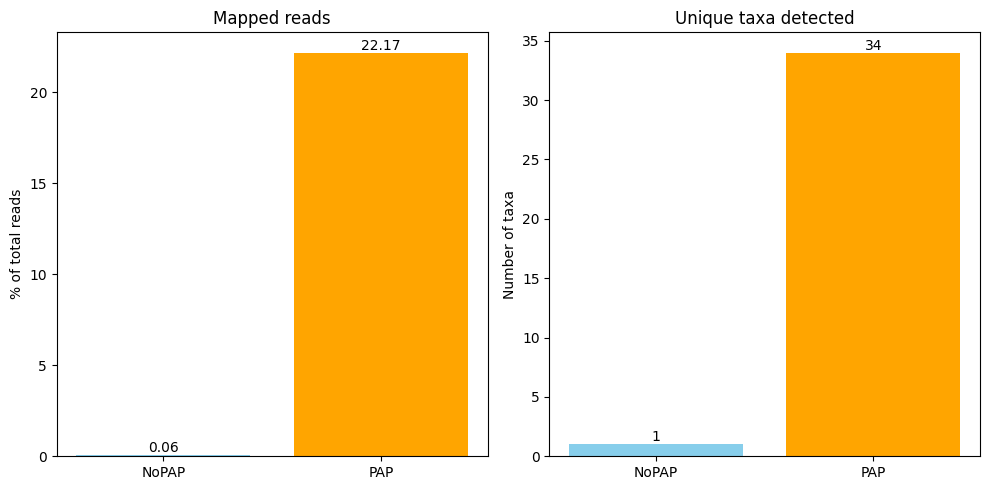

In [37]:
import matplotlib.pyplot as plt

# ---- INPUT FILES ----
kraken_files = [
    "/gpfs/commons/home/mgarbulowski/016_proj_shm/ntekas_et_al_papNoPap/SRR30622113_nopap/SRR30622113_2_k2.csv",
    "/gpfs/commons/home/mgarbulowski/016_proj_shm/ntekas_et_al_papNoPap/SRR30622109_pap/SRR30622109_2_k2.csv"
]

fastq_files = [
    "/gpfs/commons/home/mgarbulowski/016_proj_shm/ntekas_et_al_papNoPap/SRR30622113_nopap/SRR30622113_2_fastped.fastq",
    "/gpfs/commons/home/mgarbulowski/016_proj_shm/ntekas_et_al_papNoPap/SRR30622109_pap/SRR30622109_2_fastped.fastq"
]

labels = ["NoPAP", "PAP"]

# ---- CALCULATE METRICS ----
human_taxid = 9606
cutoff_fraction = 0.005       # 0.05% of total reads
min_absolute_reads = 10        # minimum reads per taxon

mapped_percent = []
unique_taxa = []

for kfile, ffile in zip(kraken_files, fastq_files):

    total_reads = count_fastq_reads(ffile)

    mapped_reads = count_filtered_reads(kfile, total_reads)
    percent = (mapped_reads / total_reads) * 100

    taxa = count_filtered_unique_taxa(kfile, total_reads)

    mapped_percent.append(percent)
    unique_taxa.append(taxa)

# ---- PLOTTING ----
fig, axes = plt.subplots(1, 2, figsize=(10,5))

colors = ["skyblue", "orange"]

# subplot 1 — mapped reads %
axes[0].bar(labels, mapped_percent, color=colors)
axes[0].set_title("Mapped reads")
axes[0].set_ylabel("% of total reads")

for i, v in enumerate(mapped_percent):
    axes[0].text(i, v, f"{v:.2f}", ha="center", va="bottom")

# subplot 2 — unique taxa
axes[1].bar(labels, unique_taxa, color=colors)
axes[1].set_title("Unique taxa detected")
axes[1].set_ylabel("Number of taxa")

for i, v in enumerate(unique_taxa):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

/scratch/ipykernel_3859029/2011883647.py:52: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2011883647.py:62: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2011883647.py:52: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_3859029/2011883647.py:62: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])


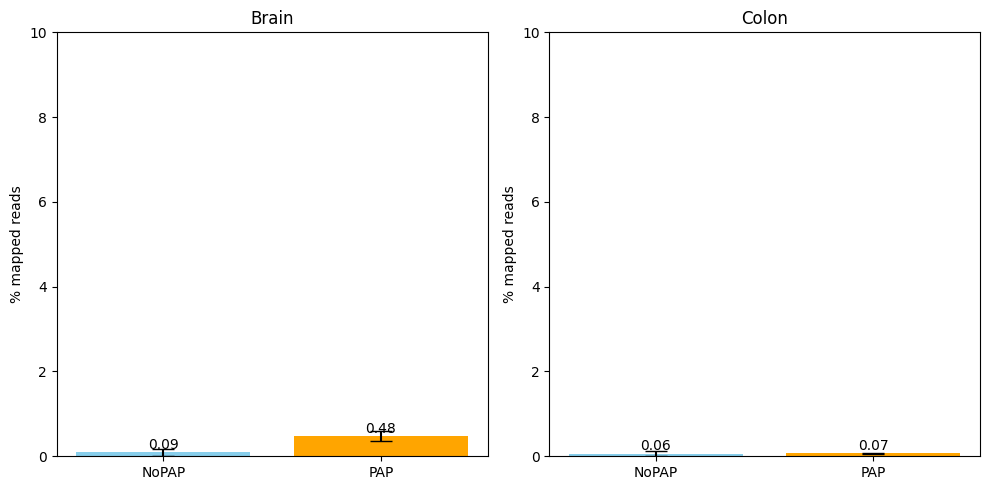

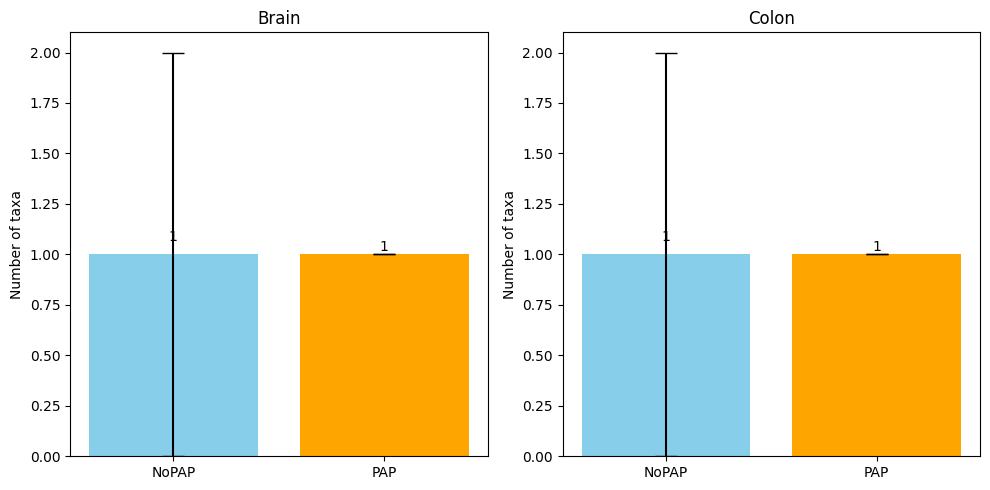

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip
import os
import glob

# ---- USER INPUT ----
main_folder = "/gpfs/commons/home/mgarbulowski/016_proj_shm/polyA_v2/mouse/"  # set this to your main folder
# Metadata per library
df_full = pd.DataFrame({
    "Sample_ID": ["Lib-1","Lib-2","Lib-3","Lib-4","Lib-5","Lib-6","Lib-11","Lib-12"],
    "Sample_Name": [
        "Mouse brain_NoPAP a","Mouse brain_PAP a","Mouse colon_NoPAP a","Mouse colon_PAP a",
        "Mouse colon_NoPAP b","Mouse colon_PAP b","Mouse brain_NoPAP b","Mouse brain_PAP b"
    ]
})

# ---- PARAMETERS ----
human_taxid = 9606
cutoff_fraction = 0.0005    # for shallow sequencing
min_absolute_reads = 0

merged_dir = os.path.join(main_folder, "merged_kraken")
os.makedirs(merged_dir, exist_ok=True)

# ---- FUNCTIONS ----

def merge_kraken_lanes(lane_files, merged_file):
    if len(lane_files)==0:
        print(f"Warning: No lanes found to merge for {merged_file}")
        return None
    df_list = [pd.read_csv(f, header=None) for f in lane_files]
    df_merged = pd.concat(df_list, ignore_index=True)
    df_merged.to_csv(merged_file, index=False, header=False)
    return merged_file

def count_fastq_reads(fastq_file):
    if not os.path.exists(fastq_file):
        print(f"Warning: FASTQ file not found: {fastq_file}")
        return 0
    open_func = gzip.open if fastq_file.endswith(".gz") else open
    with open_func(fastq_file,"rt") as f:
        return sum(1 for _ in f)//4

def total_reads_from_lanes(fastq_files):
    return sum(count_fastq_reads(fq) for fq in fastq_files)

def count_filtered_reads(kraken_file, total_reads):
    if kraken_file is None or total_reads==0:
        return 0
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0]=="C") & (df[2]!=human_taxid)]
    taxa_counts = df[2].value_counts()
    min_reads = max(total_reads*cutoff_fraction, min_absolute_reads)
    taxa_counts = taxa_counts[taxa_counts>=min_reads]
    return taxa_counts.sum()

def count_filtered_unique_taxa(kraken_file, total_reads):
    if kraken_file is None or total_reads==0:
        return 0
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0]=="C") & (df[2]!=human_taxid)]
    taxa_counts = df[2].value_counts()
    min_reads = max(total_reads*cutoff_fraction, min_absolute_reads)
    taxa_counts = taxa_counts[taxa_counts>=min_reads]
    return len(taxa_counts)

def mean_min_max(values):
    values = np.array(values)
    if len(values)==0:
        return 0, [0,0]
    mean = np.mean(values)
    lower = mean - np.min(values)
    upper = np.max(values) - mean
    return mean, [lower, upper]

# ---- FIND LANE FILES ----
# ---- FIND LANE FILES ----
kraken_files_per_lib = []
fastq_files_per_lib = []

for lib in df_full["Sample_ID"]:
    # Kraken CSVs: match any lane (_L***_), R2, ending with _k2.csv
    kraken_pattern = os.path.join(main_folder, f"{lib}_S*_L*_R2_001_k2.csv")
    kraken_files_per_lib.append(sorted(glob.glob(kraken_pattern)))
    
    # FASTQ: match any lane, R2, ending with _atroped.fastq or .fastq.gz
    fastq_pattern = os.path.join(main_folder, f"{lib}_S*_L*_R2_001_atroped.fastq")
    fastq_files_per_lib.append(sorted(glob.glob(fastq_pattern)))

df_full["kraken_lanes"] = kraken_files_per_lib
df_full["fastq_lanes"] = fastq_files_per_lib

# ---- MERGE LANES & CALCULATE METRICS ----
mapped_percent_all = []
unique_taxa_all = []

for idx,row in df_full.iterrows():
    merged_csv = os.path.join(merged_dir, f"{row['Sample_ID']}.csv")
    merge_kraken_lanes(row["kraken_lanes"], merged_csv)
    
    total_reads = total_reads_from_lanes(row["fastq_lanes"])
    mapped_reads = count_filtered_reads(merged_csv, total_reads)
    mapped_percent = mapped_reads / total_reads * 100 if total_reads>0 else 0
    unique_taxa = count_filtered_unique_taxa(merged_csv, total_reads)
    
    mapped_percent_all.append(mapped_percent)
    unique_taxa_all.append(unique_taxa)

df_full["mapped_percent"] = mapped_percent_all
df_full["unique_taxa"] = unique_taxa_all

# ---- EXTRACT METADATA ----
df_full["Tissue"] = df_full["Sample_Name"].str.contains("brain").map({True:"Brain",False:"Colon"})
df_full["Treatment"] = df_full["Sample_Name"].str.extract("(NoPAP|PAP)")
df_full["Replicate"] = df_full["Sample_Name"].str[-1]

# ---- PLOTTING ----
def plot_metric(metric,ylabel,fix_perc=False, max_fix_perc=100):
    fig, axes = plt.subplots(1,2,figsize=(10,5))
    tissues = ["Brain","Colon"]
    colors = ["skyblue","orange"]

    for i,tissue in enumerate(tissues):
        subset = df_full[df_full["Tissue"]==tissue]
        means=[]
        yerr=[]
        for treatment in ["NoPAP","PAP"]:
            vals = subset[subset["Treatment"]==treatment][metric].values
            mean, err = mean_min_max(vals)
            means.append(mean)
            yerr.append(err)

        axes[i].bar(["NoPAP","PAP"], means, yerr=np.array(yerr).T, capsize=8, color=colors)
        axes[i].set_title(tissue)
        axes[i].set_ylabel(ylabel)
        if fix_perc:
            axes[i].set_ylim(0,max_fix_perc)   # <-- FIXED SCALE

        for j,v in enumerate(means):
            axes[i].text(j, v+yerr[j][1]*0.05,
                         f"{v:.2f}" if metric=="mapped_percent" else f"{int(v)}",
                         ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

# ---- PLOT ----
plot_metric("mapped_percent","% mapped reads",fix_perc=True, max_fix_perc=10)
plot_metric("unique_taxa","Number of taxa")

In [54]:
import gzip
import os
import matplotlib.pyplot as plt

def plot_fastq_read_counts(fastq_files, sample_names=None, title="FASTQ Read Counts"):
    """
    Count reads in FASTQ/FASTQ.GZ files and plot a simple barplot.
    
    Parameters:
        fastq_files : list of str
            Paths to FASTQ or FASTQ.GZ files.
        sample_names : list of str, optional
            Names for samples (default: filenames).
        title : str
            Title for the barplot.
    """
    read_counts = []

    for fq in fastq_files:
        if not os.path.exists(fq):
            print(f"Warning: File not found: {fq}")
            read_counts.append(0)
            continue
        
        open_func = gzip.open if fq.endswith(".gz") else open
        with open_func(fq, "rt") as f:
            count = sum(1 for _ in f) // 4  # 4 lines per read
        read_counts.append(count)
    
    if sample_names is None:
        sample_names = [os.path.basename(f) for f in fastq_files]
    
    # Simple barplot
    plt.figure(figsize=(10,5))
    plt.bar(sample_names, read_counts, color="skyblue")
    plt.ylabel("Number of reads")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    for i, val in enumerate(read_counts):
        plt.text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()
    
    return read_counts

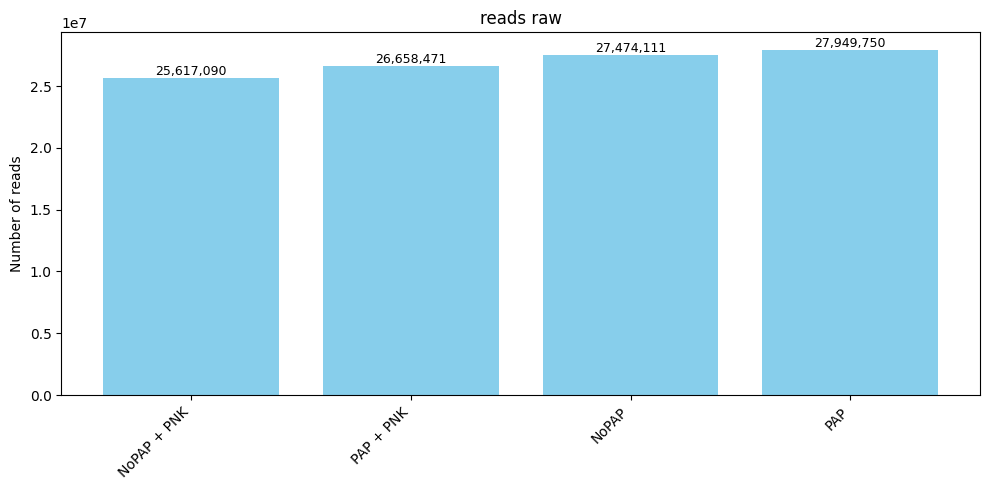

In [58]:
fastq_files = [
    "EED_gut_NoPAP_PNK_S3_R2_001.fastq.gz",
    "EED_gut_PAP_PNK_S4_R2_001.fastq.gz",
    "EED_gut_NoPAP_S1_R2_001.fastq.gz",
    "EED_gut_PAP_S2_R2_001.fastq.gz"
]

sample_names = ["NoPAP + PNK", "PAP + PNK", "NoPAP", "PAP"]

read_counts = plot_fastq_read_counts(fastq_files, sample_names, title="reads raw")

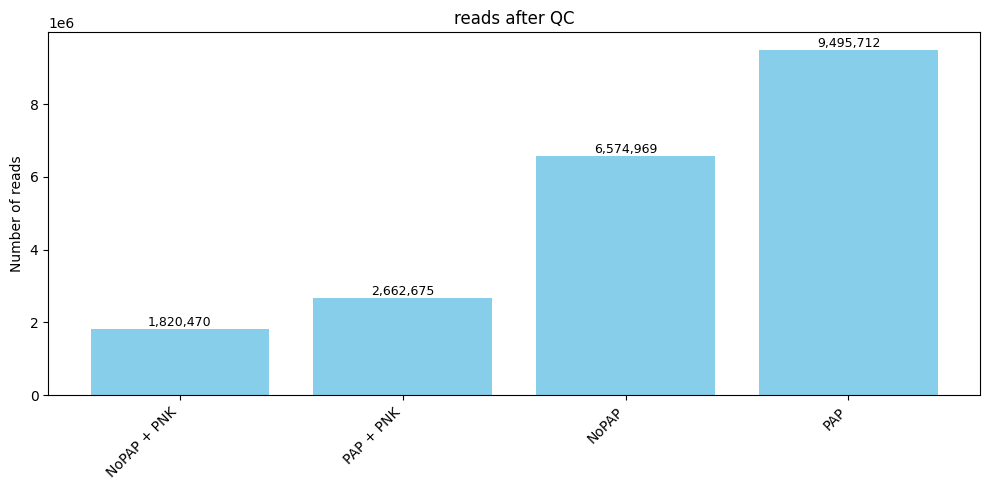

In [57]:
fastq_files = [
    "EED_gut_NoPAP_PNK_S3_R2_001_fastped.fastq",
    "EED_gut_PAP_PNK_S4_R2_001_fastped.fastq",
    "EED_gut_NoPAP_S1_R2_001_fastped.fastq",
    "EED_gut_PAP_S2_R2_001_fastped.fastq"
]

sample_names = ["NoPAP + PNK", "PAP + PNK", "NoPAP", "PAP"]

read_counts = plot_fastq_read_counts(fastq_files, sample_names, title="reads after QC")

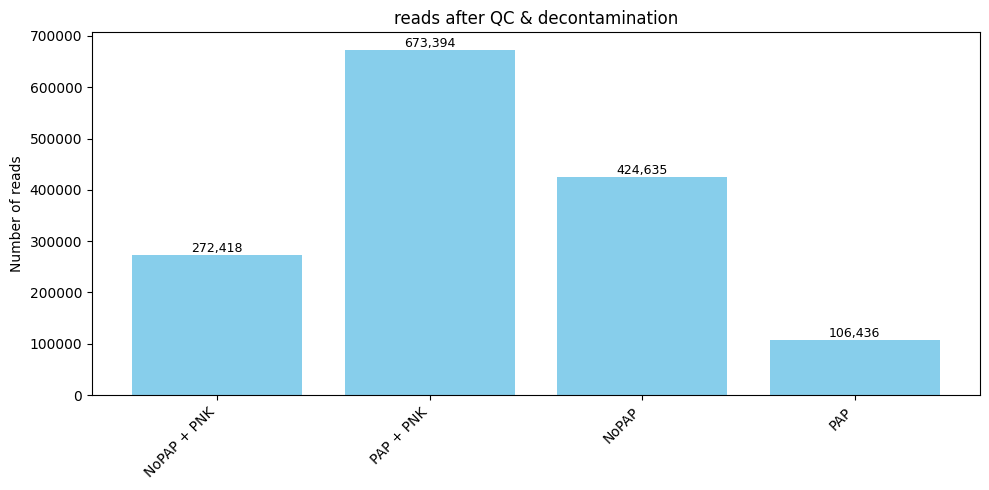

In [56]:
fastq_files = [
    "EED_gut_NoPAP_PNK_S3_R2_001_fastped_bwa_unhosted.fastq",
    "EED_gut_PAP_PNK_S4_R2_001_fastped_bwa_unhosted.fastq",
    "EED_gut_NoPAP_S1_R2_001_fastped_bwa_unhosted.fastq",
    "EED_gut_PAP_S2_R2_001_fastped_bwa_unhosted.fastq"
]

sample_names = ["NoPAP + PNK", "PAP + PNK", "NoPAP", "PAP"]

read_counts = plot_fastq_read_counts(fastq_files, sample_names, title="reads after QC & decontamination")